В блокноте выбирается датасет для обучения модели предсказания ключевых точек. Локально уже есть скачанный датасет CelebA In a Wild. Из него случайно отбираются 10000 картинок (80% тренировочные и по 10% валидационные и тестовые). Заморачиваться с атрибутами не вижу смысла, раз нужны только ключевые точки, а не редактирование изображений. В каждой картинке при помощи детектора (MTCNN) находится лицо, вырезается прямоугольник с лицом (по возможности квадрат) и сдвигаются ключевые точки. Дальше картинка с ключевыми точками ресайзится (с паддингами) в квадрат 256 * 256. Если вдруг детектор лицо не нашел, или нашел лицо не от тех ключевых точек, то это не наша картинка. Bbox'ы из датасета не используются, потому что в задании применять пайплайн придется на рандомных картинках, а не только из датасета.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from facenet_pytorch import MTCNN
import albumentations as A


Читаем ключевые точки.

In [2]:
mark_df = pd.read_csv('CelebA/Anno/list_landmarks_celeba.txt', header=1, sep='\\s+')
mark_df

,lefteye_x,lefteye_y,righteye_x,righteye_y,nose_x,nose_y,leftmouth_x,leftmouth_y,rightmouth_x,rightmouth_y
000001.jpg,165,184,244,176,196,249,194,271,266,260
000002.jpg,140,204,220,204,168,254,146,289,226,289
000003.jpg,244,104,264,105,263,121,235,134,251,140
000004.jpg,796,539,984,539,930,687,762,756,915,756
000005.jpg,273,169,328,161,298,172,283,208,323,207
...,...,...,...,...,...,...,...,...,...,...
202595.jpg,1449,201,1530,201,1491,259,1457,282,1522,286
202596.jpg,172,186,222,186,193,220,171,230,222,230
202597.jpg,81,121,113,120,101,142,81,155,116,155
202598.jpg,223,73,255,72,241,94,225,108,254,105


Смотрим произвольную картинку.

In [3]:
def show_landmarks(image, landmarks):
    """Show image with landmarks"""
    plt.imshow(image)
    plt.scatter(landmarks[:, 0], landmarks[:, 1], s=10, marker='o', c='r')


Image name: 072366.jpg
Landmarks:
[[144 158]
 [199 160]
 [167 190]
 [153 214]
 [196 214]]


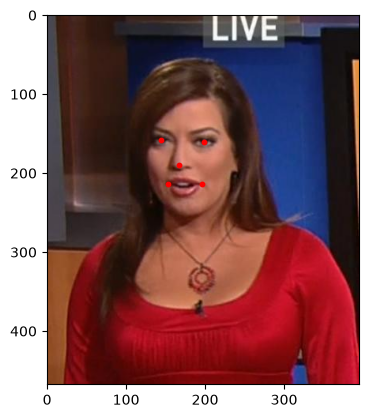

In [4]:
n = random.randint(0, len(mark_df)-1)

img_name = mark_df.index[n]
landmarks = mark_df.iloc[n]
landmarks = np.asarray(landmarks).reshape(-1, 2)

print(f'Image name: {img_name}')
print(f'Landmarks:\n{landmarks}')

img = Image.open(f'CelebA/Img/img_celeba/{img_name}')
img = np.asarray(img)

show_landmarks(img, landmarks)

plt.show()


In [5]:
img.shape

(468, 395, 3)

Посмотрим, как на картинке отработает аугментация для ресайза.

In [6]:
transform = A.Compose([
    A.LetterBox(size=(256, 256))
], keypoint_params=A.KeypointParams(coord_format='xy'))


In [7]:
result = transform(
    image=img,
    keypoints=landmarks,
)

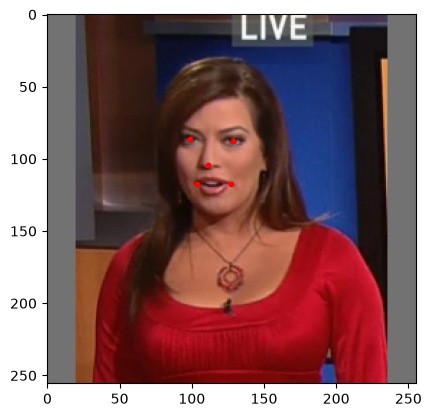

In [8]:
show_landmarks(result['image'], result['keypoints'])

In [9]:
result['image'].shape

(256, 256, 3)

In [10]:
result['keypoints']

array([[ 98.76923 ,  86.42735 ],
       [128.8547  ,  87.52137 ],
       [111.35043 , 103.931625],
       [103.692314, 117.05984 ],
       [127.213684, 117.05984 ]], dtype=float32)

Выбираем 10000 картинок для опытов (чуть с запасом, т.к MTCNN не на всех картинках находит лица).

In [11]:
indices = random.sample(range(len(mark_df)), 11000)

По каждой выбранной картинке находим на ней лицо с помощью MTCNN, кропаем, ресайзим и сохраняем в папку, ключевые точки сохраняем в файл.

In [12]:
mtcnn = MTCNN('cpu')

In [13]:
def get_box_to_crop(box, w, h, scale=1.2):
    x1, y1, x2, y2 = box
    
    size = max(x2 - x1, y2 - y1) * scale
    
    dx = (size - (x2 - x1)) / 2
    dy = (size - (y2 - y1)) / 2
    
    x1 = max(int(x1 - dx), 0)
    y1 = max(int(y1 - dy), 0)
    x2 = min(int(x2 + dx), w - 1)
    y2 = min(int(y2 + dy), h - 1)
    
    return x1, y1, x2 - x1, y2 - y1


def is_landmarks_in_box(landmarks, w, h):
    return sum(landmarks.flatten() < 0) \
        + sum(landmarks[:, 0] >= w) \
        + sum(landmarks[:, 1] >= h) == 0



In [15]:
columns = 'lefteye_x lefteye_y righteye_x righteye_y nose_x nose_y leftmouth_x leftmouth_y rightmouth_x rightmouth_y'.split()

train_df = pd.DataFrame(columns=columns)
val_df = pd.DataFrame(columns=columns)
test_df = pd.DataFrame(columns=columns)

df_to_fill = [train_df, val_df, test_df]
size_to_fill = [8 * 1024, 1024, 1024]
path_to_fill = ['cropped/train/', 'cropped/val/', 'cropped/test/']

for path in path_to_fill:
    os.makedirs(path, exist_ok=True)

transform = A.Compose([
    A.LetterBox(size=(256, 256))
], keypoint_params=A.KeypointParams(coord_format='xy'))

for n in indices:
    if not df_to_fill:
        break

    img_name = mark_df.index[n]
    img_path = f'CelebA/Img/img_celeba/{img_name}'

    img = Image.open(img_path)
    img = np.asarray(img)
    h, w = img.shape[:2]

    landmarks = mark_df.iloc[n]
    landmarks = np.asarray(landmarks).reshape(-1, 2)

    boxes, _ = mtcnn.detect(img)

    if boxes is None:
        continue
    
    box = boxes[0]
    x1, y1, w1, h1 = get_box_to_crop(box, w, h)

    landmarks = landmarks - (x1, y1)
    
    if not is_landmarks_in_box(landmarks, w1, h1):
        continue

    img = img[y1:y1+h1, x1:x1+w1]

    result = transform(
        image=img,
        keypoints=landmarks,
    )
    img = result['image']
    landmarks = result['keypoints']
    
    out_path = path_to_fill[0] + img_name
    Image.fromarray(img).save(out_path)
    
    df_to_fill[0].loc[img_name] = landmarks.reshape(-1)

    if len(df_to_fill[0]) == size_to_fill[0]:
        df_to_fill = df_to_fill[1:]
        size_to_fill = size_to_fill[1:]
        path_to_fill = path_to_fill[1:]

train_df = train_df.sort_index()
train_df.to_csv('cropped/train_landmarks.csv')

val_df = val_df.sort_index()
val_df.to_csv('cropped/val_landmarks.csv')

test_df = test_df.sort_index()
test_df.to_csv('cropped/test_landmarks.csv')


Смотрим произвольную картинку из кропнутых.

In [16]:
train_df = pd.read_csv('cropped/train_landmarks.csv', index_col=0)
train_df

,lefteye_x,lefteye_y,righteye_x,righteye_y,nose_x,nose_y,leftmouth_x,leftmouth_y,rightmouth_x,rightmouth_y
000012.jpg,92.444440,97.777780,161.77779,108.44444,120.888890,145.77779,81.777780,165.33333,151.11111,179.55556
000019.jpg,83.277110,106.409640,165.01204,106.40964,124.915660,152.67470,94.072290,188.14458,157.30120,186.60240
000053.jpg,95.150444,124.601770,165.38052,99.68141,149.522130,158.58408,124.601770,199.36282,181.23894,178.97345
000055.jpg,87.950920,109.938644,163.33742,107.58282,121.717790,151.55827,97.374230,186.89570,157.84048,188.46625
000056.jpg,99.042625,94.845900,180.45901,109.95410,150.242630,152.76065,94.006560,185.49509,155.27869,195.56721
...,...,...,...,...,...,...,...,...,...,...
202478.jpg,80.271190,112.813560,151.86441,117.15254,104.135590,162.71187,80.271190,175.72882,147.52542,184.40678
202483.jpg,80.768120,103.884060,154.97102,107.59421,110.449280,139.13043,77.057976,172.52174,156.82610,176.23189
202503.jpg,79.932490,94.514760,173.36708,92.35442,123.679320,145.82278,92.894510,186.86919,160.94514,184.16876
202531.jpg,111.993004,110.993004,181.81119,100.25175,174.650340,157.53845,133.475520,191.55244,181.81119,179.02098


Image name: 070345.jpg
Landmarks:
[[100.972115 101.992035]
 [171.34662  117.29084 ]
 [130.5498   138.70917 ]
 [ 95.87251  178.48605 ]
 [147.88846  189.70518 ]]


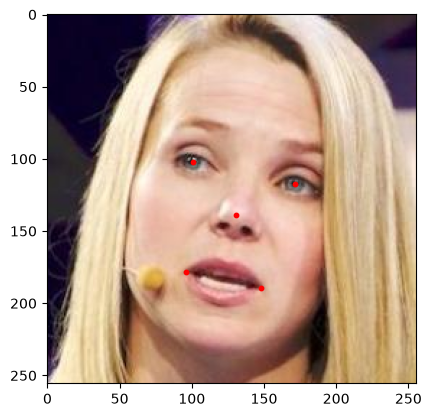

In [17]:
n = random.randint(0, len(train_df)-1)

img_name = train_df.index[n]
landmarks = train_df.iloc[n]
landmarks = np.asarray(landmarks).reshape(-1, 2)

print(f'Image name: {img_name}')
print(f'Landmarks:\n{landmarks}')

img = Image.open(f'cropped/train/{img_name}')
show_landmarks(img, landmarks)

plt.show()
